# E-commerce Customer Segmentation and Marketing Strategy Analysis

This notebook analyzes the UCI Online Retail dataset to clean transaction data, explore sales trends, create RFM customer features, build K-Means customer segments, and develop marketing recommendations.

## Business Problem

An online retailer wants to understand its customer base and design better marketing strategies. Instead of treating all customers the same, the business can use transaction behavior to identify loyal customers, promising customers, at-risk customers, and low-value or one-time buyers.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'

for folder in [RAW_DIR, PROCESSED_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

DATA_URL = 'https://archive.ics.uci.edu/static/public/352/online+retail.zip'
ZIP_PATH = RAW_DIR / 'online_retail.zip'
EXCEL_PATH = RAW_DIR / 'Online Retail.xlsx'

## Load the Dataset

The dataset can be downloaded directly from UCI. If automatic download is blocked, manually download the file from UCI and place `Online Retail.xlsx` in `data/raw`.

In [2]:
if not EXCEL_PATH.exists():
    urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(RAW_DIR)

df = pd.read_excel(EXCEL_PATH)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Cleaning

Cleaning steps:

- Remove rows with missing `CustomerID`
- Remove cancelled orders where `InvoiceNo` starts with `C`
- Remove non-positive `Quantity`
- Remove non-positive `UnitPrice`
- Convert `InvoiceDate` to datetime
- Create `Revenue = Quantity * UnitPrice`

In [3]:
cleaned = df.copy()
cleaned = cleaned.dropna(subset=['CustomerID'])
cleaned = cleaned[cleaned['Quantity'] > 0]
cleaned = cleaned[cleaned['UnitPrice'] > 0]
cleaned = cleaned[~cleaned['InvoiceNo'].astype(str).str.startswith('C')]

cleaned['InvoiceDate'] = pd.to_datetime(cleaned['InvoiceDate'])
cleaned['CustomerID'] = cleaned['CustomerID'].astype(int).astype(str)
cleaned['Revenue'] = cleaned['Quantity'] * cleaned['UnitPrice']

cleaned.to_csv(PROCESSED_DIR / 'online_retail_cleaned.csv', index=False)
cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Exploratory Data Analysis

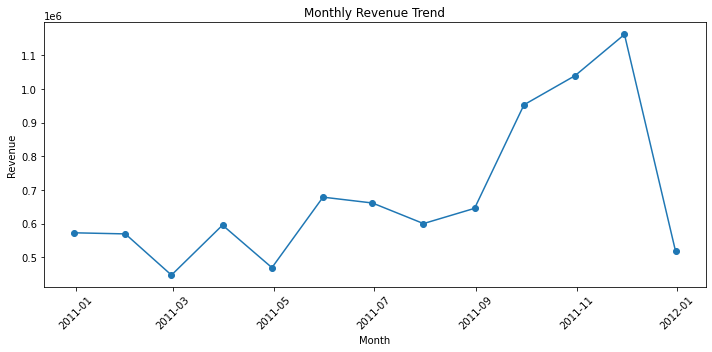

In [4]:
monthly_revenue = cleaned.set_index('InvoiceDate').resample('M')['Revenue'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue['InvoiceDate'], monthly_revenue['Revenue'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

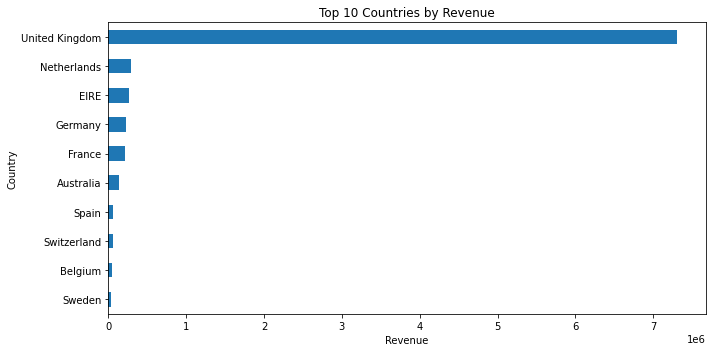

In [5]:
country_revenue = cleaned.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
country_revenue.sort_values().plot(kind='barh')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_10_countries_by_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

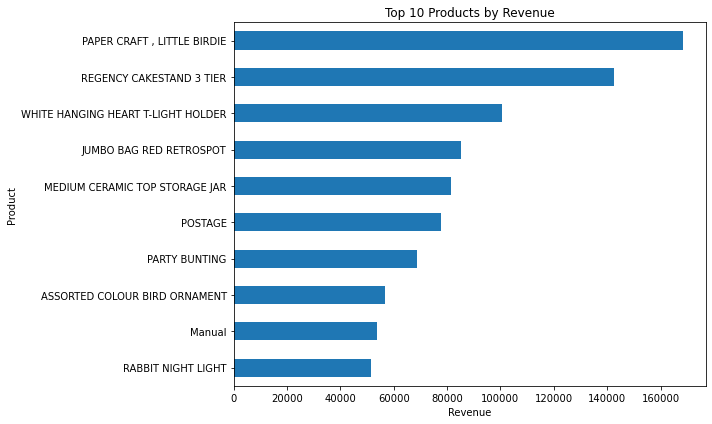

In [6]:
product_revenue = cleaned.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
product_revenue.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_10_products_by_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

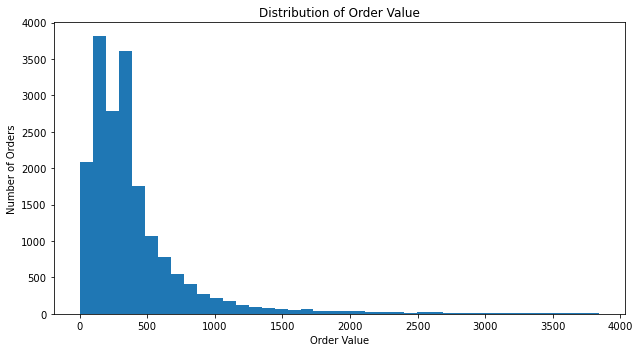

In [7]:
order_values = cleaned.groupby('InvoiceNo')['Revenue'].sum()

plt.figure(figsize=(9, 5))
order_values[order_values <= order_values.quantile(0.99)].plot(kind='hist', bins=40)
plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'order_value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

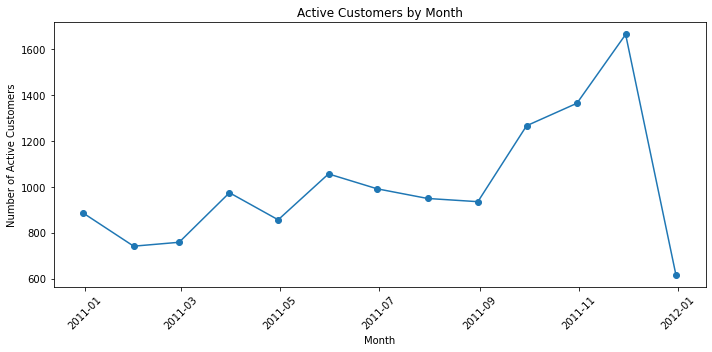

In [8]:
monthly_customers = cleaned.set_index('InvoiceDate').resample('M')['CustomerID'].nunique().reset_index(name='ActiveCustomers')

plt.figure(figsize=(10, 5))
plt.plot(monthly_customers['InvoiceDate'], monthly_customers['ActiveCustomers'], marker='o')
plt.title('Active Customers by Month')
plt.xlabel('Month')
plt.ylabel('Number of Active Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'active_customers_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

## RFM Customer Segmentation

In [9]:
snapshot_date = cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = cleaned.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


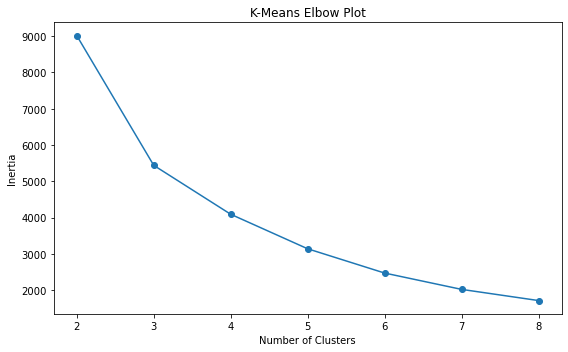

In [10]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

inertias = []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(rfm_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.title('K-Means Elbow Plot')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kmeans_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_stats = rfm.groupby('Cluster').agg(
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean')
)

labels = {}
scoring = cluster_stats.copy()
scoring['ValueScore'] = (
    scoring['Frequency'].rank(ascending=True)
    + scoring['Monetary'].rank(ascending=True)
    + scoring['Recency'].rank(ascending=False)
)

high_value_cluster = scoring['ValueScore'].idxmax()
labels[high_value_cluster] = 'High-Value Loyal Customers'

remaining = [cluster for cluster in scoring.index if cluster not in labels]
at_risk_cluster = scoring.loc[remaining, 'Recency'].idxmax()
labels[at_risk_cluster] = 'At-Risk Customers'

remaining = [cluster for cluster in scoring.index if cluster not in labels]
low_value_cluster = scoring.loc[remaining, 'Monetary'].idxmin()
labels[low_value_cluster] = 'Low-Value or One-Time Buyers'

for cluster in cluster_stats.index:
    if cluster not in labels:
        labels[cluster] = 'Potential Loyal Customers'

rfm['Segment'] = rfm['Cluster'].map(labels)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,1,Potential Loyal Customers
12347,2,7,4310.00,3,Low-Value or One-Time Buyers
12348,75,4,1797.24,3,Low-Value or One-Time Buyers
12349,19,1,1757.55,3,Low-Value or One-Time Buyers
12350,310,1,334.40,0,At-Risk Customers


In [12]:
total_revenue = rfm['Monetary'].sum()

segment_summary = (
    rfm.groupby('Segment')
    .agg(
        Customers=('Monetary', 'size'),
        AvgRecency=('Recency', 'mean'),
        AvgFrequency=('Frequency', 'mean'),
        AvgMonetary=('Monetary', 'mean'),
        TotalRevenue=('Monetary', 'sum')
    )
    .reset_index()
)

segment_summary['RevenuePct'] = segment_summary['TotalRevenue'] / total_revenue
segment_summary = segment_summary.sort_values('TotalRevenue', ascending=False)

rfm.reset_index().to_csv(PROCESSED_DIR / 'rfm_segments.csv', index=False)
segment_summary.to_csv(PROCESSED_DIR / 'segment_summary.csv', index=False)
segment_summary

,Segment,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,RevenuePct
2,Low-Value or One-Time Buyers,3052,43.920380,3.656291,1350.140532,4120628.903,0.462399
3,Potential Loyal Customers,211,15.672986,22.047393,12453.225924,2627630.670,0.294861
1,High-Value Loyal Customers,13,7.384615,82.538462,127338.313846,1655398.080,0.185762
0,At-Risk Customers,1062,248.564030,1.551789,478.107581,507750.251,0.056978


## Marketing Recommendations

- **High-Value Loyal Customers**: Provide loyalty rewards, early access, and personalized product recommendations.
- **Potential Loyal Customers**: Encourage repeat purchases with bundles, targeted email campaigns, and recommendations based on previous purchases.
- **At-Risk Customers**: Use win-back campaigns, limited-time offers, and reminders based on previous product categories.
- **Low-Value or One-Time Buyers**: Use low-cost lifecycle campaigns and cross-sell messages while avoiding expensive retention offers.